# Cristiano Ronaldo — Mr. Champions League (2015–2018)

A football-analytics walkthrough of Ronaldo's role in **Real Madrid's Champions League
three-peat**. This notebook shows the whole analysis end to end — data, SQL and charts —
in one scrollable page.

> **43 goals in 39 matches, top scorer in all three campaigns**, with **11 goals in 6
> quarter-finals** and **13 goals after the 76th minute**.

In [1]:
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, "src")
import pandas as pd, duckdb
from IPython.display import Image
import build_dataset, viz_campaign, viz_finals

## 1. Build the dataset (and validate it)

The match list (every CL game, group stage → final) comes from **openfootball**;
Ronaldo's goals are parsed from **Wikipedia**. Before trusting anything, the build checks
the per-season totals against his official tallies (16 / 12 / 15).

In [2]:
rows = build_dataset.build()
df = pd.read_csv("data/processed/ronaldo_ucl_campaign.csv")
df.head(10)

=== Ronaldo Champions League goals per campaign ===
  2015-16: parsed 16  (official 16)  OK
  2016-17: parsed 12  (official 12)  OK
  2017-18: parsed 15  (official 15)  OK
  TOTAL: 43 goals across the three winning campaigns

Wrote 39 matches -> /home/yungv/sports-analytics-portfolio/ronaldo-ucl-2016-2018/data/processed/ronaldo_ucl_campaign.csv


,season,stage,opponent,venue,rm_gf,rm_ga,result,is_knockout,ronaldo_goals,goal_minutes,matched
0,2015-16,Group stage,Shakhtar Donetsk,Home,4,0,W,False,3,55|63|81,True
1,2015-16,Group stage,Malmö FF,Away,2,0,W,False,2,29|90,True
2,2015-16,Group stage,Paris Saint-Germain,Away,0,0,D,False,0,NaN,True
3,2015-16,Group stage,Paris Saint-Germain,Home,1,0,W,False,0,NaN,True
4,2015-16,Group stage,Shakhtar Donetsk,Away,4,3,W,False,2,18|70,True
5,2015-16,Group stage,Malmö FF,Home,8,0,W,False,4,39|47|50|59,True
6,2015-16,Round of 16,AS Roma,Away,2,0,W,True,1,57,True
7,2015-16,Round of 16,AS Roma,Home,2,0,W,True,1,64,True
8,2015-16,Quarter-final,VfL Wolfsburg,Away,0,2,L,True,0,NaN,True
9,2015-16,Quarter-final,VfL Wolfsburg,Home,3,0,W,True,3,15|17|77,True


## 2. A look with SQL (DuckDB)

I query the CSV directly with SQL via DuckDB — the same approach I use with BigQuery at
work. Did he save his best for the knockouts?

In [3]:
con = duckdb.connect()
con.execute("CREATE VIEW m AS SELECT * FROM read_csv_auto('data/processed/ronaldo_ucl_campaign.csv', header=true)")
con.execute('''
    SELECT CASE WHEN is_knockout THEN 'Knockout' ELSE 'Group stage' END AS phase,
           COUNT(*) AS matches, SUM(ronaldo_goals) AS goals,
           ROUND(SUM(ronaldo_goals)*1.0/COUNT(*), 2) AS goals_per_match
    FROM m GROUP BY 1 ORDER BY goals DESC
''').df()

,phase,matches,goals,goals_per_match
0,Group stage,18,22.0,1.22
1,Knockout,21,21.0,1.00


## 3. The story in charts
Regenerate every chart, then walk through them.

In [4]:
viz_campaign.run(); viz_finals.run()

Saved campaign charts -> outputs/01..04


Saved finals visuals -> outputs/05, 06


### Top scorer in all three winning campaigns

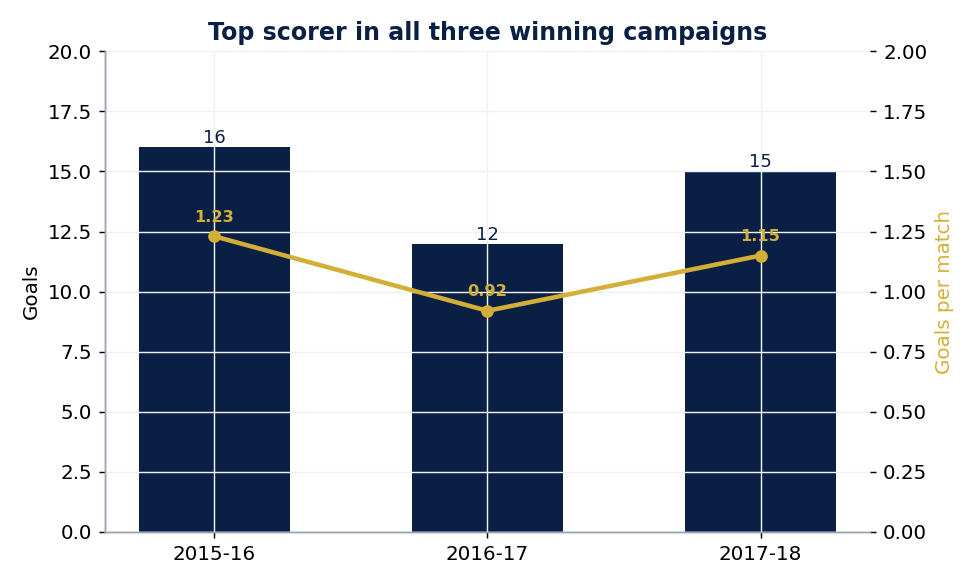

In [5]:
Image("outputs/02_goals_per_season.png")

### The clutch case — quarter-final dominance (1.83 goals/game)

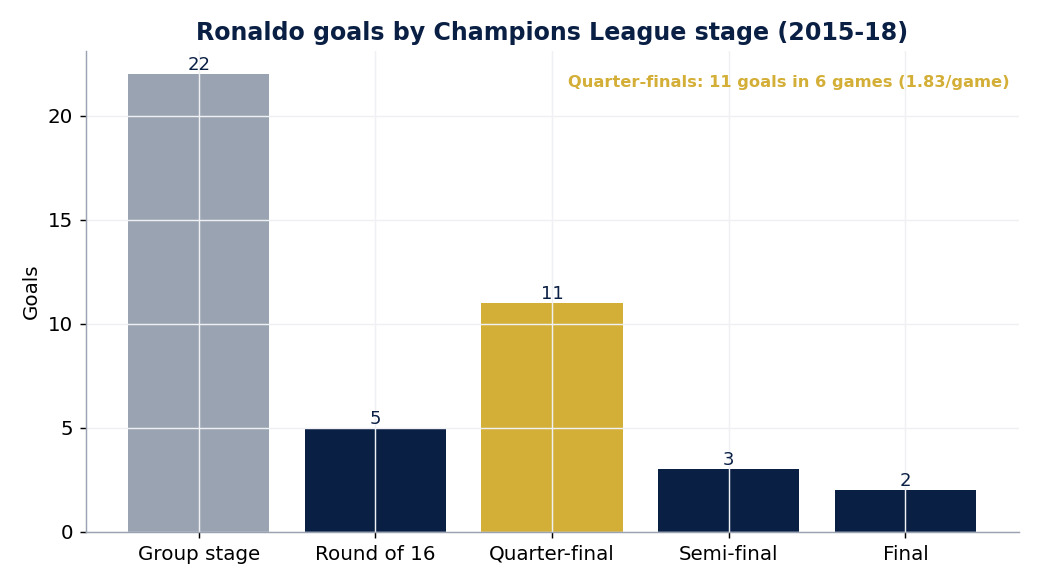

In [6]:
Image("outputs/01_goals_by_stage.png")

### A late-game killer — 13 goals after the 76th minute

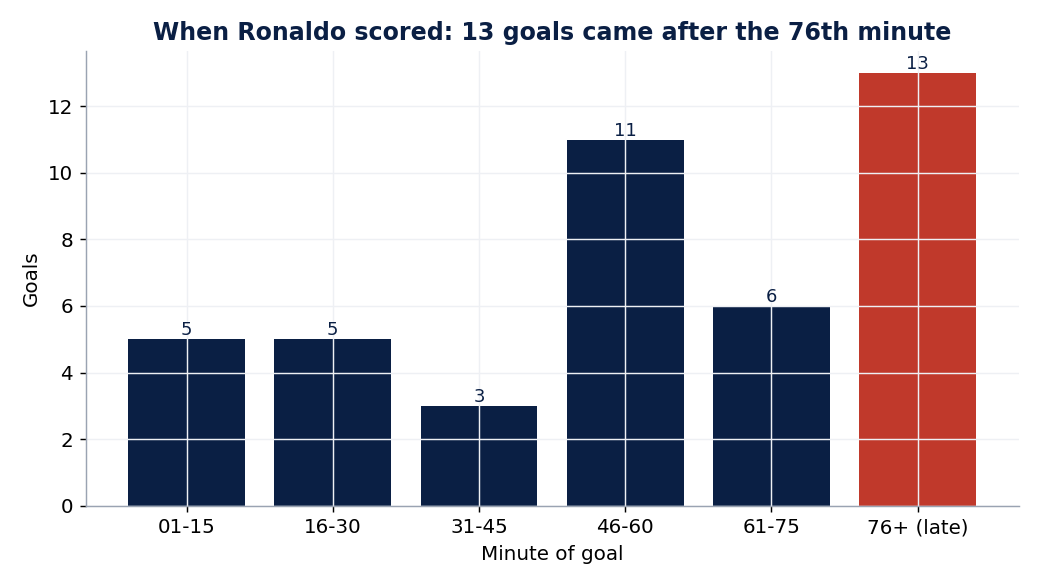

In [7]:
Image("outputs/03_goal_timing.png")

### The three finals, in event-level detail (StatsBomb)
Shot maps (marker size = xG, gold = goal):

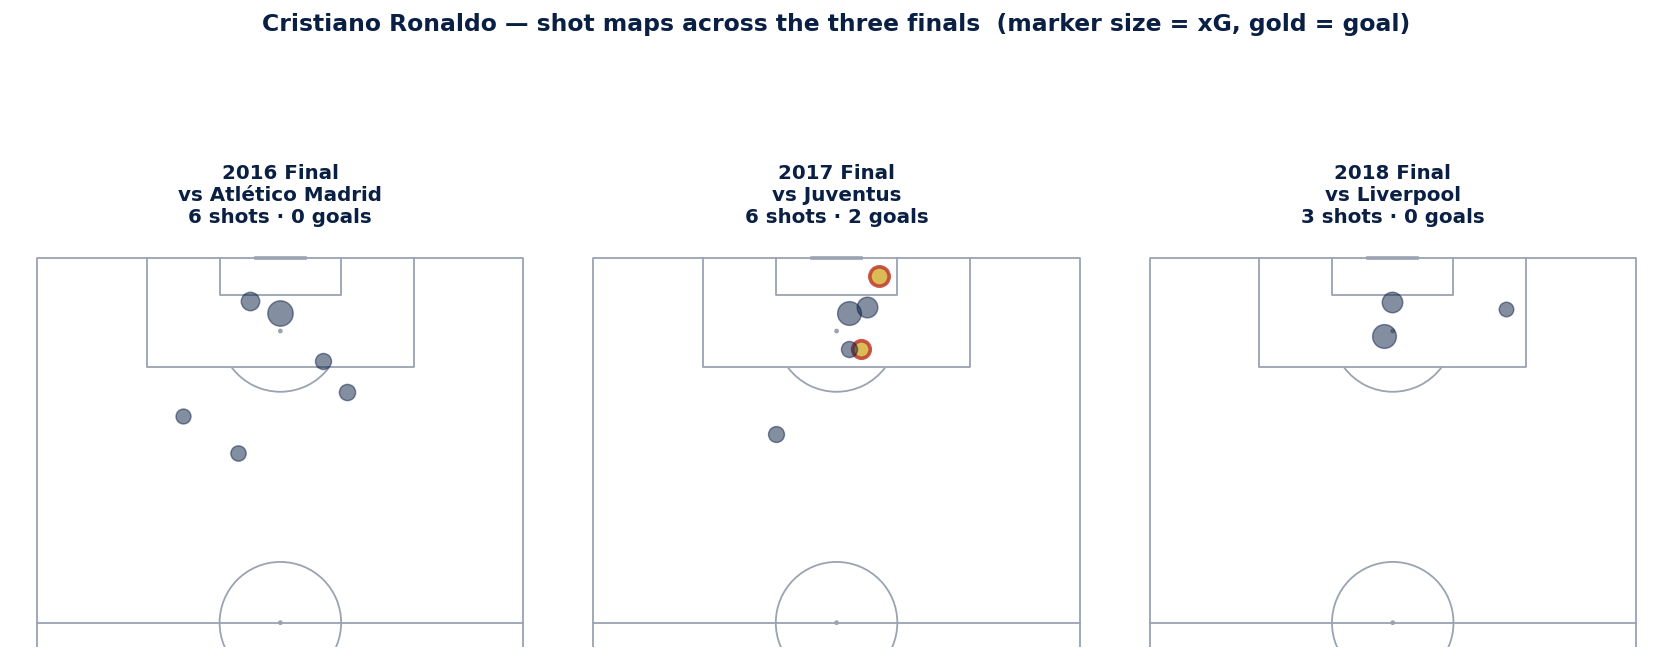

In [8]:
Image("outputs/05_finals_shot_map.png")

Touch maps — his positional evolution, wide in 2016 → central by 2018:

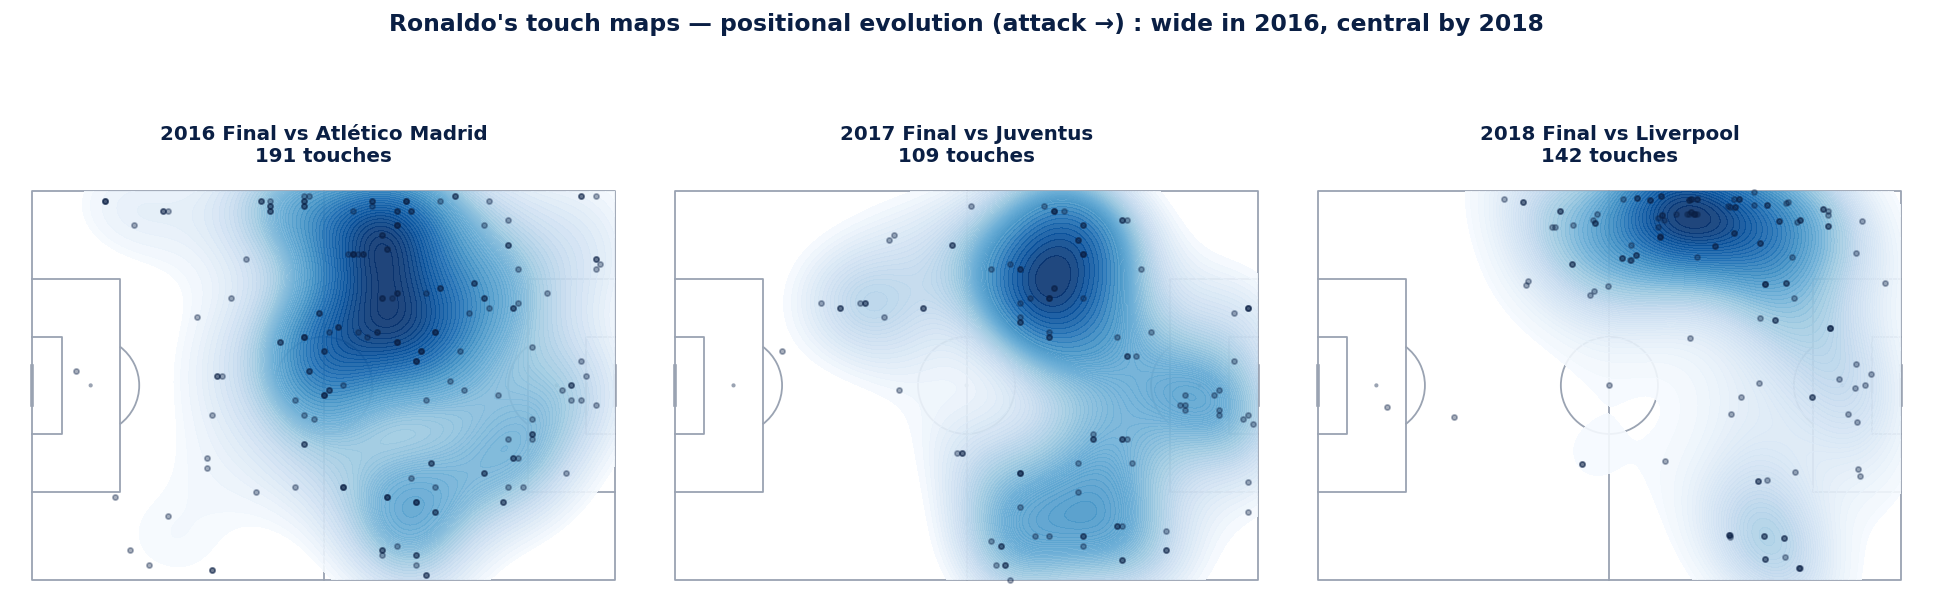

In [9]:
Image("outputs/06_finals_heatmaps.png")

## Takeaways
- Ronaldo was **top scorer in all three winning campaigns** (16 / 12 / 15 goals).
- He was at his most lethal in the **quarter-finals** and in the **closing minutes** —
  the statistical fingerprint of a clutch player.
- Full reproducible pipeline + data sources are in this repo (`src/`, `SOURCES.md`).